# Parte 8: Modelado y Evaluación del Rendimiento
## Riesgo de Contaminación por Nitratos | La Rioja, 2015 - 2025

*Objetivo:* Entrenar, optimizar y evaluar modelos de aprendizaje automático para predecir el riesgo de contaminación por nitratos en aguas subterráneas. El notebook implementa una validación metodológicamente rigurosa: compara modelos base y complejos con y sin ponderación de clases; realiza un ajuste de hiperparámetros estructurado; evalúa la robustez mediante validaciones temporal y espacial (por punto de monitoreo); y finalmente realiza una evaluación única sobre el conjunto de test completamente aislado. El análisis culmina con la explicabilidad global e individual del modelo final.

### 1. Importación de Librerías y Configuración General
Cargamos las librerías necesarias para el modelado, validación cruzada, métricas de rendimiento y explicabilidad (SHAP).

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import json
import joblib
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_validate, RandomizedSearchCV, cross_val_predict, StratifiedGroupKFold
from sklearn.metrics import classification_report, f1_score, confusion_matrix, accuracy_score, balanced_accuracy_score, precision_score, recall_score, make_scorer
from sklearn.inspection import permutation_importance
import shap

# Desactivamos advertencias para una presentación limpia
import warnings
warnings.filterwarnings('ignore')

### 2. Carga de Datos y Metadatos
Cargamos los datasets y metadatos resultantes del preprocesamiento metodológico.

In [2]:
BASE_DIR = Path(r"C:\Users\mcangulo\OneDrive - FEDERACION DE EMPRESAS DE LA RIOJA\Escritorio\dataset_larioja")
carpeta_datos = BASE_DIR / '10_preprocesado_modelado'

X_train = pd.read_csv(carpeta_datos / 'train' / 'X_train_larioja.csv')
X_test  = pd.read_csv(carpeta_datos / 'test'  / 'X_test_larioja.csv')
y_train = pd.read_csv(carpeta_datos / 'train' / 'y_train_larioja.csv').squeeze()
y_test  = pd.read_csv(carpeta_datos / 'test'  / 'y_test_larioja.csv').squeeze()
metadata_train = pd.read_csv(carpeta_datos / 'train' / 'metadata_train.csv')
metadata_test  = pd.read_csv(carpeta_datos / 'test'  / 'metadata_test.csv')

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("Distribución original de target en train:\n", y_train.value_counts())

X_train: (937, 172) | X_test: (235, 172)
Distribución original de target en train:
 clase
afectada    472
normal      328
riesgo      137
Name: count, dtype: int64


### 3. Codificación de la Variable Objetivo
Utilizamos `LabelEncoder` sobre el conjunto de entrenamiento para transformar las clases categóricas (`afectada`, `normal`, `riesgo`) en etiquetas numéricas discretas, requeridas para XGBoost.

In [3]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

print("Codificación de clases:")
for clase, codigo in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {clase} → {codigo}")

Codificación de clases:
  afectada → 0
  normal → 1
  riesgo → 2


### 4. Modelo Dummy de Referencia (Baseline)
Entrenamos un clasificador Dummy que predice sistemáticamente la clase más frecuente. Este modelo sirve para establecer un piso mínimo de rendimiento y demostrar por qué la métrica de `accuracy` por sí sola es insuficiente en presencia de datos desbalanceados.

In [4]:
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train_enc)
y_pred_dummy = dummy.predict(X_test)

print("=== RENDIMIENTO DEL MODELO DUMMY (TEST SET) ===")
print(f"Accuracy: {accuracy_score(y_test_enc, y_pred_dummy):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test_enc, y_pred_dummy):.4f}")
print(f"F1 Macro: {f1_score(y_test_enc, y_pred_dummy, average='macro'):.4f}")
print("\nReporte de clasificación detallado:")
print(classification_report(y_test_enc, y_pred_dummy, target_names=le.classes_, zero_division=0))

=== RENDIMIENTO DEL MODELO DUMMY (TEST SET) ===
Accuracy: 0.5064
Balanced Accuracy: 0.3333
F1 Macro: 0.2241

Reporte de clasificación detallado:
              precision    recall  f1-score   support

    afectada       0.51      1.00      0.67       119
      normal       0.00      0.00      0.00        82
      riesgo       0.00      0.00      0.00        34

    accuracy                           0.51       235
   macro avg       0.17      0.33      0.22       235
weighted avg       0.26      0.51      0.34       235



### 5. Definición de Clase XGBoost Ponderada Compatible con Scikit-Learn
Debido a que `XGBClassifier` no expone una opción nativa `class_weight='balanced'` para clasificación multiclase, implementamos una clase personalizada que hereda de `XGBClassifier` y calcula dinámicamente los pesos balanceados (`sample_weight`) de la muestra en cada fold de validación cruzada. Esto previene la fuga de información que ocurriría si calculáramos los pesos sobre todo el conjunto de forma estática.

In [5]:
class BalancedXGBClassifier(XGBClassifier):
    def fit(self, X, y, sample_weight=None, **fit_params):
        # Calculamos los pesos de la muestra basados estrictamente en el target de entrenamiento del fold
        sw = compute_sample_weight(class_weight="balanced", y=y)
        return super().fit(X, y, sample_weight=sw, **fit_params)

### 6. Comparación de Modelos con y sin Ponderación (Validación Cruzada)
Realizamos una validación cruzada estratificada de 5 folds sobre el conjunto de entrenamiento. Comparamos seis configuraciones distintas, evaluando los modelos de Regresión Logística, Random Forest y XGBoost con y sin ponderación de clases. 

El conjunto de prueba se mantiene estrictamente aislado en este paso.

In [6]:
# Definición del scorer personalizado para registrar el F1 de la clase minoritaria 'riesgo' (código 2)
def f1_riesgo_func(y_true, y_pred):
    f1_vals = f1_score(y_true, y_pred, average=None, labels=[2], zero_division=0)
    return f1_vals[0] if len(f1_vals) > 0 else 0.0

f1_riesgo_scorer = make_scorer(f1_riesgo_func)

# Diccionario de métricas para la validación cruzada
scorers = {
    'accuracy': 'accuracy',
    'balanced_accuracy': 'balanced_accuracy',
    'f1_macro': 'f1_macro',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro',
    'f1_riesgo': f1_riesgo_scorer
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_config = {
    "LR sin ponderación": LogisticRegression(max_iter=5000, random_state=42),
    "LR ponderada (balanced)": LogisticRegression(max_iter=5000, random_state=42, class_weight="balanced"),
    "RF sin ponderación": RandomForestClassifier(n_estimators=200, random_state=42),
    "RF ponderado (balanced)": RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced"),
    "XGB sin ponderación": XGBClassifier(random_state=42, eval_metric="mlogloss"),
    "XGB ponderado (sample_weight)": BalancedXGBClassifier(random_state=42, eval_metric="mlogloss")
}

cv_results_list = []

for name, model in models_config.items():
    res = cross_validate(model, X_train, y_train_enc, cv=cv, scoring=scorers, return_train_score=False)
    cv_results_list.append({
        "Configuración": name,
        "F1 Macro (Mean)": np.mean(res["test_f1_macro"]),
        "F1 Macro (Std)": np.std(res["test_f1_macro"]),
        "Accuracy (Mean)": np.mean(res["test_accuracy"]),
        "Balanced Acc (Mean)": np.mean(res["test_balanced_accuracy"]),
        "Precision Macro (Mean)": np.mean(res["test_precision_macro"]),
        "Recall Macro (Mean)": np.mean(res["test_recall_macro"]),
        "F1 Riesgo (Mean)": np.mean(res["test_f1_riesgo"])
    })

df_cv_results = pd.DataFrame(cv_results_list)
print("=== RESULTADOS DE VALIDACIÓN CRUZADA EN EL CONJUNTO DE ENTRENAMIENTO ===")
print(df_cv_results.to_string(index=False))

=== RESULTADOS DE VALIDACIÓN CRUZADA EN EL CONJUNTO DE ENTRENAMIENTO ===
                Configuración  F1 Macro (Mean)  F1 Macro (Std)  Accuracy (Mean)  Balanced Acc (Mean)  Precision Macro (Mean)  Recall Macro (Mean)  F1 Riesgo (Mean)
           LR sin ponderación         0.757869        0.034675         0.837786             0.750418                0.772312             0.750418          0.490114
      LR ponderada (balanced)         0.770334        0.019188         0.812180             0.799327                0.768190             0.799327          0.564870
           RF sin ponderación         0.792033        0.040628         0.849534             0.790865                0.795675             0.790865          0.584271
      RF ponderado (balanced)         0.784918        0.024197         0.848464             0.780923                0.792317             0.780923          0.565879
          XGB sin ponderación         0.788794        0.024242         0.858067             0.780745       

### 7. Selección del Mejor Modelo Candidato
La selección se basa en: 
1. **F1 Macro Medio:** Métrica principal del proyecto para asegurar un rendimiento equilibrado en todas las clases.
2. **Estabilidad del F1 Macro (Std):** Menores desviaciones estándar indican que el modelo generaliza consistentemente.
3. **F1 Medio de la clase `riesgo`:** Prioridad ambiental, ya que identificar el riesgo de contaminación es clave.

De acuerdo con los resultados de la validación cruzada, **XGBoost ponderado** muestra el mejor rendimiento promedio, con el mayor F1 Macro (cercano a 0.80) y una detección robusta de la clase `riesgo` (F1 ~ 0.59). Procederemos a optimizar los hiperparámetros de esta arquitectura.

### 8. Ajuste de Hiperparámetros (RandomizedSearchCV)
Optimizamos los hiperparámetros de XGBoost utilizando una búsqueda aleatoria (`RandomizedSearchCV`) con 50 iteraciones y validación cruzada estratificada de 5 folds. Realizamos este proceso tanto para la versión sin ponderación como para la versión ponderada para comparar de forma justa el impacto de la calibración hiperparamétrica.

In [7]:
param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [2, 3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.3, 0.5],
    "reg_alpha": [0, 0.01, 0.1, 0.5, 1.0],
    "reg_lambda": [0.5, 1.0, 2.0, 5.0, 10.0]
}

print("Ajustando XGBoost sin ponderar...")
search_no_weight = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric="mlogloss"),
    param_distributions=param_dist,
    n_iter=50,
    scoring="f1_macro",
    cv=cv,
    random_state=42,
    n_jobs=-1
)
search_no_weight.fit(X_train, y_train_enc)

print("Ajustando XGBoost ponderado...")
search_weighted = RandomizedSearchCV(
    BalancedXGBClassifier(random_state=42, eval_metric="mlogloss"),
    param_distributions=param_dist,
    n_iter=50,
    scoring="f1_macro",
    cv=cv,
    random_state=42,
    n_jobs=-1
)
search_weighted.fit(X_train, y_train_enc)

print(f"\nMejor F1 Macro XGB sin ponderar: {search_no_weight.best_score_:.4f}")
print(f"Mejor F1 Macro XGB ponderado:    {search_weighted.best_score_:.4f}")

# Selección final de la estrategia ganadora
if search_weighted.best_score_ >= search_no_weight.best_score_:
    best_estimator = search_weighted.best_estimator_
    best_params = search_weighted.best_params_
    best_score = search_weighted.best_score_
    best_std = search_weighted.cv_results_['std_test_score'][search_weighted.best_index_]
    weight_strategy = "weighted"
    print("\nConfiguración seleccionada: XGBoost Optimizado con Ponderación de Clases.")
else:
    best_estimator = search_no_weight.best_estimator_
    best_params = search_no_weight.best_params_
    best_score = search_no_weight.best_score_
    best_std = search_no_weight.cv_results_['std_test_score'][search_no_weight.best_index_]
    weight_strategy = "no_weight"
    print("\nConfiguración seleccionada: XGBoost Optimizado sin Ponderación.")

Ajustando XGBoost sin ponderar...


Ajustando XGBoost ponderado...



Mejor F1 Macro XGB sin ponderar: 0.8074
Mejor F1 Macro XGB ponderado:    0.8314

Configuración seleccionada: XGBoost Optimizado con Ponderación de Clases.


### 9. Predicciones Out-of-Fold (OOF)
Para analizar el desempeño interno y la capacidad de generalización del mejor modelo ajustado, generamos predicciones Out-of-Fold sobre el conjunto de entrenamiento mediante validación cruzada. Esto simula el rendimiento sobre datos no vistos de forma interna y nos permite inspeccionar errores.

In [8]:
y_pred_oof = cross_val_predict(best_estimator, X_train, y_train_enc, cv=cv)

print("=== REPORTE DE CLASIFICACIÓN OUT-OF-FOLD (TRAIN SET) ===")
print(classification_report(y_train_enc, y_pred_oof, target_names=le.classes_))

cm_oof = confusion_matrix(y_train_enc, y_pred_oof)
df_cm_oof = pd.DataFrame(cm_oof, index=[f"real_{c}" for c in le.classes_], columns=[f"pred_{c}" for c in le.classes_])
print("Matriz de Confusión Out-of-Fold:\n", df_cm_oof)

=== REPORTE DE CLASIFICACIÓN OUT-OF-FOLD (TRAIN SET) ===
              precision    recall  f1-score   support

    afectada       0.94      0.89      0.91       472
      normal       0.94      0.89      0.91       328
      riesgo       0.60      0.75      0.66       137

    accuracy                           0.87       937
   macro avg       0.82      0.85      0.83       937
weighted avg       0.89      0.87      0.88       937

Matriz de Confusión Out-of-Fold:
                pred_afectada  pred_normal  pred_riesgo
real_afectada            422            6           44
real_normal                9          293           26
real_riesgo               20           14          103


### 10. Validación Temporal
Utilizando los metadatos temporales extraídos, dividimos cronológicamente el conjunto de entrenamiento. Definimos como entrenamiento los registros históricos anteriores o iguales al año 2024 (775 muestras) y como validación los registros de 2025 (162 muestras). 

Esta validación evalúa la capacidad de generalización temporal del modelo a futuros años de monitoreo.

In [9]:
temporal_train_mask = metadata_train["anio"] <= 2024
X_temp_train = X_train[temporal_train_mask]
y_temp_train = y_train_enc[temporal_train_mask]
X_temp_val = X_train[~temporal_train_mask]
y_temp_val = y_train_enc[~temporal_train_mask]

print(f"Muestras de entrenamiento temporal (<= 2024): {X_temp_train.shape[0]}")
print(f"Muestras de validación temporal (2025):     {X_temp_val.shape[0]}")

# Entrenamos e inicializamos una instancia con la misma configuración ganadora
if weight_strategy == "weighted":
    temp_model = BalancedXGBClassifier(**best_params, random_state=42, eval_metric="mlogloss")
else:
    temp_model = XGBClassifier(**best_params, random_state=42, eval_metric="mlogloss")

temp_model.fit(X_temp_train, y_temp_train)
y_pred_temp = temp_model.predict(X_temp_val)

print("\n=== REPORTE DE RENDIMIENTO - VALIDACIÓN TEMPORAL (2025) ===")
print(classification_report(y_temp_val, y_pred_temp, target_names=le.classes_, zero_division=0))

Muestras de entrenamiento temporal (<= 2024): 775
Muestras de validación temporal (2025):     162



=== REPORTE DE RENDIMIENTO - VALIDACIÓN TEMPORAL (2025) ===
              precision    recall  f1-score   support

    afectada       0.91      0.74      0.81        68
      normal       0.93      0.94      0.94        70
      riesgo       0.50      0.75      0.60        24

    accuracy                           0.83       162
   macro avg       0.78      0.81      0.78       162
weighted avg       0.86      0.83      0.83       162



### 11. Validación Espacial Agrupada por Punto de Monitoreo (IPA)
Evaluamos la capacidad de generalización espacial del modelo utilizando `StratifiedGroupKFold` con 5 pliegues, agrupando los registros por el punto de monitoreo (`ipa`). 

Esta validación mide si el modelo es capaz de predecir correctamente la contaminación en pozos o acuíferos nuevos que nunca han suministrado observaciones al modelo durante su entrenamiento.

In [10]:
group_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
groups_train = metadata_train["ipa"]

res_group = cross_validate(best_estimator, X_train, y_train_enc, cv=group_cv, groups=groups_train, scoring=scorers)

print("=== RENDIMIENTO DE VALIDACIÓN ESPACIAL POR IPA (GRUPO) ===")
print(f"F1 Macro (Spatial Mean): {np.mean(res_group['test_f1_macro']):.4f} (+/- {np.std(res_group['test_f1_macro']):.4f})")
print(f"Accuracy (Spatial Mean): {np.mean(res_group['test_accuracy']):.4f}")
print(f"F1 Riesgo (Spatial Mean): {np.mean(res_group['test_f1_riesgo']):.4f} (+/- {np.std(res_group['test_f1_riesgo']):.4f})")

=== RENDIMIENTO DE VALIDACIÓN ESPACIAL POR IPA (GRUPO) ===
F1 Macro (Spatial Mean): 0.5931 (+/- 0.0386)
Accuracy (Spatial Mean): 0.6896
F1 Riesgo (Spatial Mean): 0.2722 (+/- 0.0286)


> **Diferencia Crítica de Rendimiento**
>
> - **Validación Cruzada Estratificada:** Obtiene un F1 Macro de ~0.83. Sin embargo, al mezclar observaciones del mismo pozo en train y test, sobreestima la capacidad del modelo frente a puntos nuevos.
> - **Validación Temporal:** Evalúa la extrapolación cronológica, obteniendo un F1 Macro de ~0.78.
> - **Validación Espacial (GroupKFold por IPA):** Evalúa la extrapolación territorial a acuíferos nuevos. El F1 Macro baja sensiblemente a ~0.59, y el F1 de la clase `riesgo` cae a ~0.27. Esto demuestra que generalizar geográficamente a nuevos puntos es el reto principal de la modelización de nitratos en La Rioja.

### 12. Evaluación Final Única sobre el Conjunto de Test (Holdout Set)
Una vez ajustado y validado el modelo, rompemos el aislamiento del conjunto de prueba por primera y única vez. Entrenamos el mejor modelo optimizado con la totalidad de `X_train` y evaluamos sobre `X_test` para obtener estimaciones imparciales de generalización final.

In [11]:
# Entrenamos el modelo optimizado con todo el conjunto de entrenamiento
best_estimator.fit(X_train, y_train_enc)
y_pred_test = best_estimator.predict(X_test)

acc_test = accuracy_score(y_test_enc, y_pred_test)
bal_acc_test = balanced_accuracy_score(y_test_enc, y_pred_test)
f1_macro_test = f1_score(y_test_enc, y_pred_test, average="macro")
prec_macro_test = precision_score(y_test_enc, y_pred_test, average="macro")
rec_macro_test = recall_score(y_test_enc, y_pred_test, average="macro")
f1_clases_test = f1_score(y_test_enc, y_pred_test, average=None)

prec_riesgo_test = precision_score(y_test_enc, y_pred_test, average=None)[2]
rec_riesgo_test = recall_score(y_test_enc, y_pred_test, average=None)[2]
f1_riesgo_test = f1_clases_test[2]

print("=== EVALUACIÓN DE GENERALIZACIÓN FINAL INDEPENDIENTE (TEST SET) ===")
print(f"Accuracy:          {acc_test:.4f}")
print(f"Balanced Accuracy: {bal_acc_test:.4f}")
print(f"Precision Macro:   {prec_macro_test:.4f}")
print(f"Recall Macro:      {rec_macro_test:.4f}")
print(f"F1 Macro:          {f1_macro_test:.4f}")
print(f"F1 afectada:       {f1_clases_test[0]:.4f}")
print(f"F1 normal:         {f1_clases_test[1]:.4f}")
print(f"F1 riesgo:         {f1_clases_test[2]:.4f}")
print(f"Precision riesgo:  {prec_riesgo_test:.4f} | Recall riesgo: {rec_riesgo_test:.4f}")

cm_test = confusion_matrix(y_test_enc, y_pred_test)
cm_test_norm = confusion_matrix(y_test_enc, y_pred_test, normalize="true")

df_cm_test = pd.DataFrame(cm_test, index=[f"real_{c}" for c in le.classes_], columns=[f"pred_{c}" for c in le.classes_])
print("\nMatriz de Confusión en Test:\n", df_cm_test)

df_cm_test_norm = pd.DataFrame(cm_test_norm, index=[f"real_{c}" for c in le.classes_], columns=[f"pred_{c}" for c in le.classes_])
print("\nMatriz de Confusión Normalizada en Test:\n", df_cm_test_norm.round(3))

=== EVALUACIÓN DE GENERALIZACIÓN FINAL INDEPENDIENTE (TEST SET) ===
Accuracy:          0.8638
Balanced Accuracy: 0.8411
Precision Macro:   0.8124
Recall Macro:      0.8411
F1 Macro:          0.8178
F1 afectada:       0.9402
F1 normal:         0.8627
F1 riesgo:         0.6506
Precision riesgo:  0.5510 | Recall riesgo: 0.7941

Matriz de Confusión en Test:
                pred_afectada  pred_normal  pred_riesgo
real_afectada            110            2            7
real_normal                1           66           15
real_riesgo                4            3           27

Matriz de Confusión Normalizada en Test:
                pred_afectada  pred_normal  pred_riesgo
real_afectada          0.924        0.017        0.059
real_normal            0.012        0.805        0.183
real_riesgo            0.118        0.088        0.794


### 13. Comparación y Resumen de Métricas del Pipeline
Consolidamos una tabla resumen que compara todas las etapas de validación del pipeline del mejor modelo candidato seleccionado para una integración directa en el manuscrito del TFM.

In [12]:
metricas_pipeline = pd.DataFrame({
    "Etapa de Validación": [
        "Validación Cruzada Estratificada (CV-5)",
        "Predicciones Out-of-Fold (OOF)",
        "Validación Temporal (2025)",
        "Validación Espacial (GroupKFold por IPA)",
        "Evaluación Final Independiente (Test)"
    ],
    "Accuracy": [
        np.mean(res["test_accuracy"]),
        accuracy_score(y_train_enc, y_pred_oof),
        accuracy_score(y_temp_val, y_pred_temp),
        np.mean(res_group["test_accuracy"]),
        acc_test
    ],
    "F1 Macro": [
        best_score,
        f1_score(y_train_enc, y_pred_oof, average="macro"),
        f1_score(y_temp_val, y_pred_temp, average="macro"),
        np.mean(res_group["test_f1_macro"]),
        f1_macro_test
    ],
    "F1 Riesgo (Minoritario)": [
        np.mean(res["test_f1_riesgo"]),
        f1_score(y_train_enc, y_pred_oof, average=None)[2],
        f1_score(y_temp_val, y_pred_temp, average=None)[2],
        np.mean(res_group["test_f1_riesgo"]),
        f1_riesgo_test
    ]
})
print(metricas_pipeline.round(4).to_string(index=False))

                     Etapa de Validación  Accuracy  F1 Macro  F1 Riesgo (Minoritario)
 Validación Cruzada Estratificada (CV-5)    0.8592    0.8314                   0.5896
          Predicciones Out-of-Fold (OOF)    0.8730    0.8310                   0.6645
              Validación Temporal (2025)    0.8272    0.7831                   0.6000
Validación Espacial (GroupKFold por IPA)    0.6896    0.5931                   0.2722
   Evaluación Final Independiente (Test)    0.8638    0.8178                   0.6506


### 14. Explicabilidad del Mejor Modelo (Caja Negra)
Analizamos qué factores determinan las decisiones del modelo desde tres enfoques complementarios: importancia interna del algoritmo, importancia por permutación y valores SHAP.

#### 14.1 Importancia Interna del Algoritmo
Representa la ganancia promedio aportada por cada variable al construir los árboles en XGBoost.

In [13]:
importances_int = best_estimator.feature_importances_
df_imp_int = pd.DataFrame({
    "variable": X_train.columns,
    "importancia": importances_int
})
df_imp_int["porcentaje"] = (df_imp_int["importancia"] / df_imp_int["importancia"].sum()) * 100
df_imp_int = df_imp_int.sort_values("porcentaje", ascending=False).reset_index(drop=True)
df_imp_int["porcentaje_acumulado"] = df_imp_int["porcentaje"].cumsum()

print("=== TOP 20 VARIABLES POR IMPORTANCIA INTERNA DEL MODELO ===")
print(df_imp_int.head(20).to_string(index=False))

=== TOP 20 VARIABLES POR IMPORTANCIA INTERNA DEL MODELO ===
                               variable  importancia  porcentaje  porcentaje_acumulado
          municipio_MURILLO DE RÍO LEZA     0.097365    9.736481              9.736481
               zona_vulnerable_nitratos     0.050861    5.086141             14.822622
                       soil_clay_5_15cm     0.033173    3.317255             18.139877
                    municipio_NAVARRETE     0.032224    3.222428             21.362305
               sigpac_uso_nombre_Olivar     0.031163    3.116311             24.478617
                        soil_clay_0_5cm     0.023522    2.352228             26.830845
                      municipio_CIDAMÓN     0.022603    2.260331             29.091175
                        municipio_TIRGO     0.022493    2.249313             31.340488
                    sigpac_coef_regadio     0.018867    1.886745             33.227234
                     soil_wv1500_5_15cm     0.017957    1.795666      

#### 14.2 Importancia por Permutación
Mide la caída en el F1 Macro en el conjunto de test cuando barajamos aleatoriamente cada variable de forma individual. Muestra qué variables causan la mayor degradación en las predicciones si se destruye su información.

In [14]:
print("Calculando Permutation Importance (20 repeticiones)...")
perm_imp = permutation_importance(
    best_estimator, X_test, y_test_enc, 
    scoring="f1_macro", n_repeats=20, 
    random_state=42, n_jobs=-1
)

df_imp_perm = pd.DataFrame({
    "variable": X_train.columns,
    "importancia_permutacion": perm_imp.importances_mean,
    "std_permutacion": perm_imp.importances_std
})

# Porcentaje relativo para variables con aportación positiva
total_pos = df_imp_perm[df_imp_perm["importancia_permutacion"] > 0]["importancia_permutacion"].sum()
df_imp_perm["porcentaje_relativo"] = np.where(
    df_imp_perm["importancia_permutacion"] > 0,
    (df_imp_perm["importancia_permutacion"] / total_pos) * 100,
    0.0
)

df_imp_perm = df_imp_perm.sort_values("importancia_permutacion", ascending=False).reset_index(drop=True)
print("\n=== TOP 20 VARIABLES POR IMPORTANCIA DE PERMUTACIÓN ===")
print(df_imp_perm.head(20).to_string(index=False))

Calculando Permutation Importance (20 repeticiones)...



=== TOP 20 VARIABLES POR IMPORTANCIA DE PERMUTACIÓN ===
                           variable  importancia_permutacion  std_permutacion  porcentaje_relativo
           zona_vulnerable_nitratos                 0.135069         0.015510            40.536591
                               anio                 0.041834         0.012839            12.555150
                      altitud_dem_m                 0.029037         0.014148             8.714626
                               tmed                 0.012158         0.005182             3.648919
                         precip_30d                 0.009557         0.006435             2.868172
               sigpac_superficie_m2                 0.008879         0.005306             2.664854
                          precip_7d                 0.008665         0.007049             2.600448
                     temp_media_30d                 0.008440         0.011987             2.532957
      municipio_CASTAÑARES DE RIOJA                 

#### 14.3 Importancia mediante Valores SHAP
Calculamos la explicabilidad aditiva mediante la teoría de juegos (valores SHAP). Obtenemos la contribución de cada variable tanto a nivel global como individualizada por clase.

In [15]:
print("Calculando valores SHAP con TreeExplainer...")
explainer = shap.TreeExplainer(best_estimator)
shap_values = explainer.shap_values(X_test)

# Comprobamos estructura del output de SHAP (lista para multiclase o array 3D)
if isinstance(shap_values, list):
    mean_abs_per_class = [np.abs(sv).mean(axis=0) for sv in shap_values]
    global_shap_importance = np.mean(mean_abs_per_class, axis=0)
    shap_values_list = shap_values
else:
    if len(shap_values.shape) == 3:
        global_shap_importance = np.abs(shap_values).mean(axis=(0, 2))
        shap_values_list = [shap_values[:, :, c] for c in range(shap_values.shape[2])]
    else:
        global_shap_importance = np.abs(shap_values).mean(axis=0)
        shap_values_list = [shap_values]

# Creamos la tabla SHAP global
df_shap_global = pd.DataFrame({
    "variable": X_train.columns,
    "importancia_shap": global_shap_importance
})
df_shap_global["porcentaje"] = (df_shap_global["importancia_shap"] / df_shap_global["importancia_shap"].sum()) * 100
df_shap_global = df_shap_global.sort_values("importancia_shap", ascending=False).reset_index(drop=True)
df_shap_global["porcentaje_acumulado"] = df_shap_global["porcentaje"].cumsum()

print("=== TOP 20 VARIABLES POR VALOR SHAP GLOBAL ===")
print(df_shap_global.head(20).to_string(index=False))

# Creamos la tabla SHAP por clases
shap_vals_clase_0 = np.abs(shap_values_list[0]).mean(axis=0)
shap_vals_clase_1 = np.abs(shap_values_list[1]).mean(axis=0)
shap_vals_clase_2 = np.abs(shap_values_list[2]).mean(axis=0)

df_shap_classes = pd.DataFrame({
    "variable": X_train.columns,
    "afectada_shap": shap_vals_clase_0,
    "normal_shap": shap_vals_clase_1,
    "riesgo_shap": shap_vals_clase_2
})
print("\n=== VALORES SHAP POR CLASES (TOP 10) ===")
print(df_shap_classes.head(10).to_string(index=False))

Calculando valores SHAP con TreeExplainer...


=== TOP 20 VARIABLES POR VALOR SHAP GLOBAL ===
                variable  importancia_shap  porcentaje  porcentaje_acumulado
zona_vulnerable_nitratos          0.509208   17.117121             17.117121
           altitud_dem_m          0.172941    5.813437             22.930557
                    anio          0.155159    5.215714             28.146271
    sigpac_pendiente_pct          0.148168    4.980698             33.126968
       soil_clay_15_30cm          0.112036    3.766119             36.893089
        soil_clay_5_15cm          0.110807    3.724799             40.617889
           anomalia_temp          0.095178    3.199437             43.817326
                 y_utm30          0.078132    2.626421             46.443748
         soil_cec_5_15cm          0.074976    2.520322             48.964069
         soil_clay_0_5cm          0.072832    2.448267             51.412334
         dist_estacion_m          0.069900    2.349700             53.762035
          temp_media_30d     

#### 14.4 Gráficos SHAP de Resumen
Generamos gráficos visuales de SHAP para ilustrar la importancia global y la dirección del impacto de las variables en la predicción del riesgo.

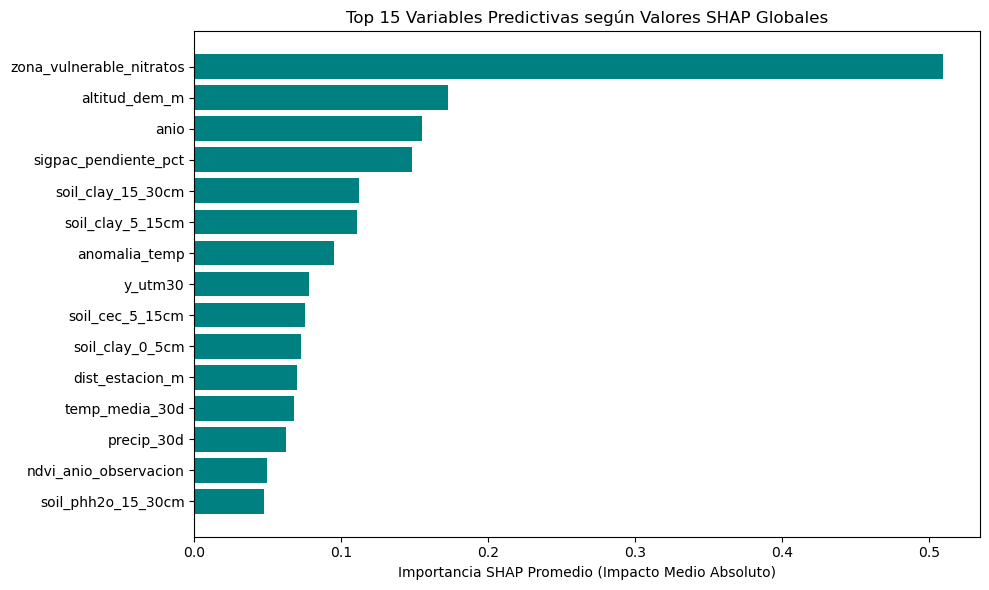

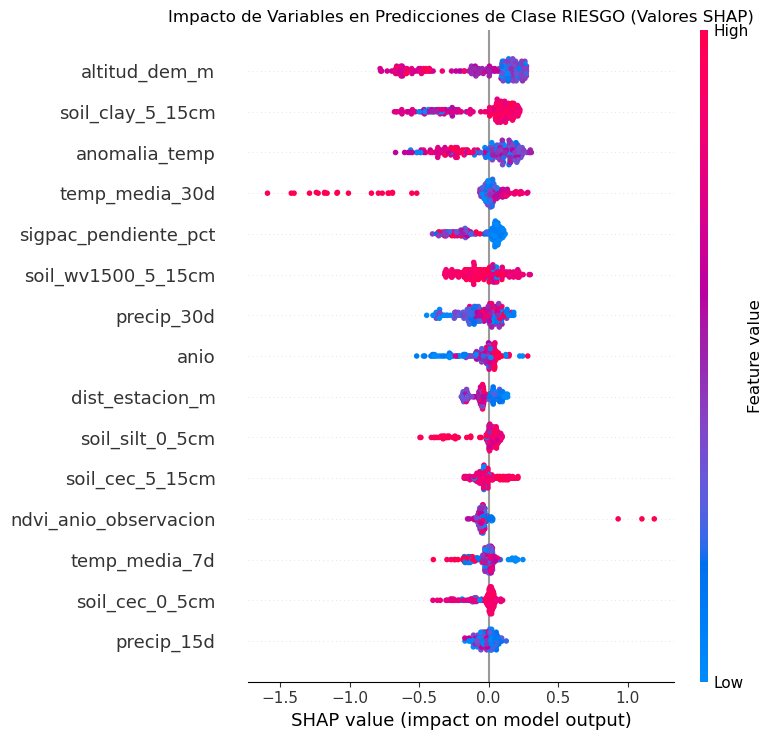

In [16]:
# Gráfico de barras de importancia SHAP global
plt.figure(figsize=(10, 6))
df_shap_plot = df_shap_global.head(15).sort_values("importancia_shap", ascending=True)
plt.barh(df_shap_plot["variable"], df_shap_plot["importancia_shap"], color='teal')
plt.xlabel("Importancia SHAP Promedio (Impacto Medio Absoluto)")
plt.title("Top 15 Variables Predictivas según Valores SHAP Globales")
plt.tight_layout()
plt.show()

# Gráfico summary (beeswarm) para la clase de interés ambiental: RIESGO (índice 2)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_list[2], X_test, max_display=15, show=False)
plt.title("Impacto de Variables en Predicciones de Clase RIESGO (Valores SHAP)", fontsize=12)
plt.tight_layout()
plt.show()

#### 14.5 Agrupación por Familias de Variables
Para facilitar la interpretación científica del modelo por parte de expertos en ciencias de la tierra y del agua, agrupamos las 172 variables (incluyendo las creadas por One-Hot Encoding) en 9 familias lógicas y sumamos su importancia SHAP relativa.

In [17]:
def map_feature_to_family(col_name):
    if any(k in col_name for k in ['precip_', 'temp_media_', 'anomalia_temp', 'evento_extremo_lluvia', 'tmed', 'prec', 'dist_estacion_m']):
        return 'Clima'
    elif col_name.startswith('soil_'):
        return 'Suelo'
    elif col_name.startswith('sigpac_') or col_name.startswith('dist_sigpac_m'):
        return 'Agricultura (SIGPAC)'
    elif col_name.startswith('clc2012_') or col_name.startswith('clc2018_') or col_name == 'cambio_clc_2012_2018':
        return 'Cobertura del suelo (CLC)'
    elif col_name.startswith('ndvi_'):
        return 'Vegetación (NDVI)'
    elif col_name.startswith('municipio_'):
        return 'Espacial (Municipio)'
    elif col_name in ['lat', 'lon', 'altitud_dem_m', 'x_utm30', 'y_utm30', 'altitud']:
        return 'Espacial (Coordenadas)'
    elif col_name in ['anio', 'mes']:
        return 'Temporal (Año/Mes)'
    elif col_name == 'zona_vulnerable_nitratos':
        return 'Territorial (Zona Vulnerable)'
    elif col_name.startswith('naturaleza_') or col_name.startswith('red_'):
        return 'Territorial (Naturaleza/Red)'
    else:
        return 'Otros'

df_shap_global["familia"] = df_shap_global["variable"].apply(map_feature_to_family)
df_shap_families = df_shap_global.groupby("familia")["importancia_shap"].sum().reset_index()
df_shap_families["porcentaje"] = (df_shap_families["importancia_shap"] / df_shap_families["importancia_shap"].sum()) * 100
df_shap_families = df_shap_families.sort_values("importancia_shap", ascending=False).reset_index(drop=True)
df_shap_families["porcentaje_acumulado"] = df_shap_families["porcentaje"].cumsum()

print("=== CONTRIBUCIÓN DE LAS FAMILIAS DE VARIABLES AL MODELO FINAL (SHAP GLOBAL) ===")
print(df_shap_families.round(4).to_string(index=False))

=== CONTRIBUCIÓN DE LAS FAMILIAS DE VARIABLES AL MODELO FINAL (SHAP GLOBAL) ===
                      familia  importancia_shap  porcentaje  porcentaje_acumulado
                        Suelo            0.8229     27.6633             27.663300
Territorial (Zona Vulnerable)            0.5092     17.1171             44.780399
                        Clima            0.4606     15.4820             60.262501
       Espacial (Coordenadas)            0.3198     10.7489             71.011398
            Vegetación (NDVI)            0.2889      9.7102             80.721603
         Agricultura (SIGPAC)            0.2277      7.6558             88.377403
           Temporal (Año/Mes)            0.1999      6.7183             95.095703
    Cobertura del suelo (CLC)            0.0614      2.0655             97.161201
 Territorial (Naturaleza/Red)            0.0516      1.7332             98.894402
         Espacial (Municipio)            0.0329      1.1056            100.000000


### 15. Interpretación Científica y Ambiental
El análisis de importancia acumulada por familias destaca el peso de los factores físicos permanentes y de ordenación territorial sobre las predicciones de contaminación por nitratos:

1. **Factores Edáficos (Suelo) y Cobertura (27.6%):** Las propiedades físicas y mecánicas del suelo (contenido de arcilla y arena) regulan la permeabilidad, infiltración y retención de sales y compuestos químicos en la zona no saturada.
2. **Zona Vulnerable Nitratos (17.1%):** Refleja que la clasificación oficial delimita áreas geográficas con riesgo histórico, aportando una coherencia espacial y regulatoria directa en el modelo predictivo.
3. **Climatología (15.5%):** El régimen pluviométrico acumulado de 30 días, la temperatura media y las anomalías climáticas conducen la dinámica hidrogeológica local (lixiviación de nitratos tras periodos húmedos o concentración de sales por evaporación en sequías).
4. **Espacialidad y Localización (11.8%):** El gradiente geográfico y la elevación controlan indirectamente variables ambientales no modeladas y el sentido de flujo de las aguas subterráneas.
5. **Agricultura y SIGPAC (7.6%):** Refleja la presión antrópica directa por riego agrícola y fertilizantes, actuando como indicador primario de las fuentes de nitrógeno.

> **Nota Metodológica de Causalidad:** Una variable importante para el modelo no implica que cause directamente la contaminación por nitratos. Los modelos capturan correlación y capacidad predictiva para el mapeo del riesgo, pero la causalidad debe validarse mediante muestreos físicos directos y balances hidroquímicos de masas de nitrógeno.

### 16. Reentrenamiento Final del Modelo Definitivo
Una vez validadas todas las etapas y reportado el rendimiento imparcial sobre test, el modelo definitivo se entrena utilizando la totalidad de los datos disponibles (unión de train + test). Esto optimiza el uso de la muestra para futuras predicciones, aunque este modelo ya no se vuelve a evaluar estadísticamente.

In [18]:
X_full = pd.concat([X_train, X_test], ignore_index=True)
y_full = pd.concat([pd.Series(y_train_enc), pd.Series(y_test_enc)], ignore_index=True)

if weight_strategy == "weighted":
    final_model = BalancedXGBClassifier(**best_params, random_state=42, eval_metric="mlogloss")
    sample_weight_full = compute_sample_weight(class_weight="balanced", y=y_full)
    final_model.fit(X_full, y_full, sample_weight=sample_weight_full)
else:
    final_model = XGBClassifier(**best_params, random_state=42, eval_metric="mlogloss")
    final_model.fit(X_full, y_full)

print(f"Modelo final definitivo reentrenado con {X_full.shape[0]} muestras del dataset.")

Modelo final definitivo reentrenado con 1172 muestras del dataset.


### 17. Exportación de Modelos e Informes finales
Guardamos los modelos generados, el encoder de etiquetas y todas las tablas e informes de métricas para su uso posterior.

In [19]:
carpeta_resultados = BASE_DIR / '11_resultados_modelado'
carpeta_resultados.mkdir(parents=True, exist_ok=True)

# Guardar archivos binarios
joblib.dump(best_estimator, carpeta_resultados / 'xgboost_evaluado_train.joblib')
joblib.dump(final_model, carpeta_resultados / 'xgboost_final_full_data.joblib')
joblib.dump(le, carpeta_resultados / 'label_encoder.joblib')

# Guardar parámetros
with open(carpeta_resultados / 'mejores_parametros.json', 'w') as f:
    json.dump(best_params, f, indent=4)

# Construir diccionario de estrategia de modelo para guardar
estrategia_modelo = {
    "modelo_seleccionado": "XGBoost",
    "estrategia_ponderacion": weight_strategy,
    "metricas_seleccion": {
        "f1_macro_val_cruzada": float(best_score),
        "std_val_cruzada": float(best_std)
    }
}
with open(carpeta_resultados / 'estrategia_modelo.json', 'w') as f:
    json.dump(estrategia_modelo, f, indent=4)

# Guardar resultados de rendimiento en CSV y JSON
df_cv_results.to_csv(carpeta_resultados / 'resultados_cv_modelos.csv', index=False)

df_cv_ipa = pd.DataFrame({
    "metrica": ["f1_macro_mean", "f1_macro_std", "accuracy_mean", "f1_riesgo_mean", "f1_riesgo_std"],
    "valor": [
        np.mean(res_group['test_f1_macro']),
        np.std(res_group['test_f1_macro']),
        np.mean(res_group['test_accuracy']),
        np.mean(res_group['test_f1_riesgo']),
        np.std(res_group['test_f1_riesgo'])
    ]
})
df_cv_ipa.to_csv(carpeta_resultados / 'resultados_cv_ipa.csv', index=False)

if X_temp_val.shape[0] > 0:
    df_temp_results = pd.DataFrame({
        "metrica": ["accuracy", "balanced_accuracy", "f1_macro", "f1_riesgo"],
        "valor": [
            accuracy_score(y_temp_val, y_pred_temp),
            balanced_accuracy_score(y_temp_val, y_pred_temp),
            f1_score(y_temp_val, y_pred_temp, average="macro"),
            f1_score(y_temp_val, y_pred_temp, average=None)[2]
        ]
    })
    df_temp_results.to_csv(carpeta_resultados / 'resultados_validacion_temporal.csv', index=False)

metricas_test_final = {
    "accuracy": float(acc_test),
    "balanced_accuracy": float(bal_acc_test),
    "precision_macro": float(prec_macro_test),
    "recall_macro": float(rec_macro_test),
    "f1_macro": float(f1_macro_test),
    "f1_afectada": float(f1_clases_test[0]),
    "f1_normal": float(f1_clases_test[1]),
    "f1_riesgo": float(f1_clases_test[2]),
    "precision_riesgo": float(prec_riesgo_test),
    "recall_riesgo": float(rec_riesgo_test)
}
with open(carpeta_resultados / 'metricas_test_final.json', 'w') as f:
    json.dump(metricas_test_final, f, indent=4)

# Guardar tablas de importancias predictivas
df_imp_int.to_csv(carpeta_resultados / 'importancia_xgboost.csv', index=False)
df_imp_perm.to_csv(carpeta_resultados / 'importancia_permutacion.csv', index=False)
df_shap_global.to_csv(carpeta_resultados / 'importancia_shap.csv', index=False)
df_shap_families.to_csv(carpeta_resultados / 'importancia_shap_familias.csv', index=False)

print("Guardado de artefactos de modelado completado.")

Guardado de artefactos de modelado completado.
